<a href="https://colab.research.google.com/github/aadzy/ML-lab-2547201/blob/Lab-9/SVM_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part A: Support Vector Machine (SVM)

### Task 1: Load the dataset and perform necessary preprocessing.

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Breast Cancer Wisconsin (Diagnostic) Dataset
bc_data = load_breast_cancer()
X = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
y = pd.Series(bc_data.target)

print("Dataset loaded successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Display the first 5 rows of the features and target variable
print("\nFirst 5 rows of features (X):")
display(X.head())
print("\nFirst 5 rows of target (y):")
display(y.head())

Dataset loaded successfully.
Features (X) shape: (569, 30)
Target (y) shape: (569,)

First 5 rows of features (X):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



First 5 rows of target (y):


,0
0,0
1,0
2,0
3,0
4,0


#### Preprocessing: Checking for missing values and scaling features.

In [2]:
# Check for missing values
print("\nMissing values in features (X):\n", X.isnull().sum().sum())
print("Missing values in target (y):\n", y.isnull().sum())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFeatures scaled successfully. First 5 rows of scaled features (X_scaled):")
display(X_scaled.head())


Missing values in features (X):
 0
Missing values in target (y):
 0

Features scaled successfully. First 5 rows of scaled features (X_scaled):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### Task 2: Split the dataset into training and testing sets (80:20).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set features (X_train) shape: {X_train.shape}")
print(f"Testing set features (X_test) shape: {X_test.shape}")
print(f"Training set target (y_train) shape: {y_train.shape}")
print(f"Testing set target (y_test) shape: {y_test.shape}")

# Check the distribution of target in train and test sets to ensure stratification worked
print("\nDistribution of target in training set:\n", y_train.value_counts(normalize=True))
print("\nDistribution of target in testing set:\n", y_test.value_counts(normalize=True))


Training set features (X_train) shape: (455, 30)
Testing set features (X_test) shape: (114, 30)
Training set target (y_train) shape: (455,)
Testing set target (y_test) shape: (114,)

Distribution of target in training set:
 1    0.626374
0    0.373626
Name: proportion, dtype: float64

Distribution of target in testing set:
 1    0.631579
0    0.368421
Name: proportion, dtype: float64


### Task 3: Train an SVM classifier using a Linear Kernel and explore hyper parameter tuning.

We will start with a basic Linear SVM and then explore hyperparameter tuning using GridSearchCV.

In [4]:
# Initialize and train an SVM classifier with a Linear Kernel
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)

print("Linear SVM classifier trained successfully.")

# Hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for linear kernel
param_grid_linear = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear']
}

# Initialize GridSearchCV
grid_search_linear = GridSearchCV(SVC(random_state=42), param_grid_linear, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_linear.fit(X_train, y_train)

print("\nGridSearchCV for Linear SVM completed.")
print("Best parameters for Linear SVM: ", grid_search_linear.best_params_)
print("Best cross-validation accuracy for Linear SVM: {:.2f}".format(grid_search_linear.best_score_))

# Get the best linear SVM model
best_svm_linear = grid_search_linear.best_estimator_

Linear SVM classifier trained successfully.

GridSearchCV for Linear SVM completed.
Best parameters for Linear SVM:  {'C': 0.1, 'kernel': 'linear'}
Best cross-validation accuracy for Linear SVM: 0.98


### Task 4: Evaluate the model using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.

We will evaluate both the initially trained linear SVM and the best linear SVM found through hyperparameter tuning.


--- Initial Linear SVM Evaluation ---
Accuracy: 0.9737
Precision: 0.9859
Recall: 0.9722
F1 Score: 0.9790
Confusion Matrix:
 [[41  1]
 [ 2 70]]


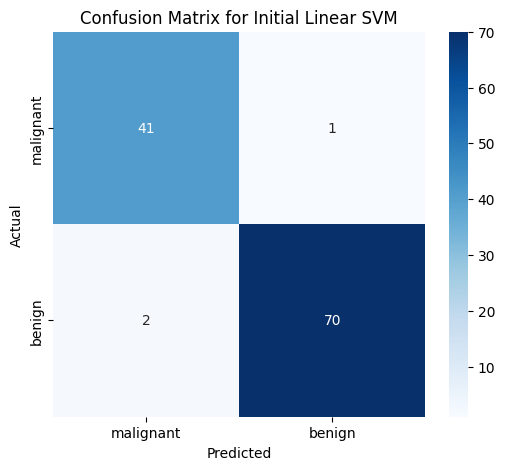


--- Best Linear SVM (Tuned) Evaluation ---
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861
Confusion Matrix:
 [[41  1]
 [ 1 71]]


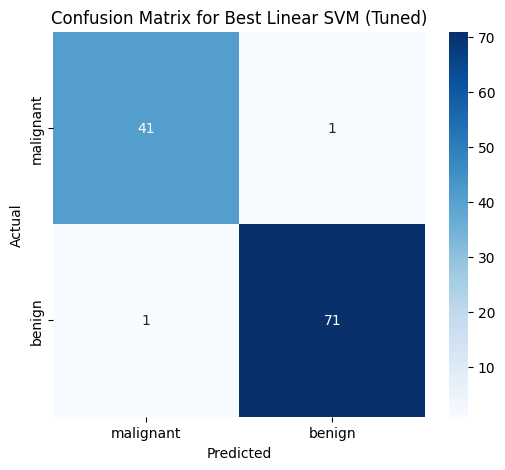

In [5]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", cm)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=bc_data.target_names, yticklabels=bc_data.target_names)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluate the initial Linear SVM
evaluate_model(svm_linear, X_test, y_test, "Initial Linear SVM")

# Evaluate the best Linear SVM from GridSearchCV
evaluate_model(best_svm_linear, X_test, y_test, "Best Linear SVM (Tuned)")

### Task 5: Summarize your observations.

Based on the evaluation metrics above, we can summarize the performance of the Linear SVM models.

### Train SVM classifiers using different kernels (RBF and Polynomial) and explore hyperparameter tuning.


#### RBF Kernel SVM

In [6]:
# Initialize and train an SVM classifier with RBF Kernel
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)

print("RBF SVM classifier trained successfully.")

# Hyperparameter tuning using GridSearchCV for RBF kernel
param_grid_rbf = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid_search_rbf = GridSearchCV(SVC(random_state=42), param_grid_rbf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rbf.fit(X_train, y_train)

print("\nGridSearchCV for RBF SVM completed.")
print("Best parameters for RBF SVM: ", grid_search_rbf.best_params_)
print("Best cross-validation accuracy for RBF SVM: {:.2f}".format(grid_search_rbf.best_score_))

# Get the best RBF SVM model
best_svm_rbf = grid_search_rbf.best_estimator_

RBF SVM classifier trained successfully.

GridSearchCV for RBF SVM completed.
Best parameters for RBF SVM:  {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation accuracy for RBF SVM: 0.98


#### Polynomial Kernel SVM

In [7]:
# Initialize and train an SVM classifier with Polynomial Kernel
svm_poly = SVC(kernel='poly', random_state=42)
svm_poly.fit(X_train, y_train)

print("Polynomial SVM classifier trained successfully.")

# Hyperparameter tuning using GridSearchCV for Polynomial kernel
param_grid_poly = {
    'C': [0.1, 1, 10, 100],
    'degree': [2, 3, 4],
    'gamma': [0.001, 0.01, 0.1, 1], # 'auto' or 'scale' also common
    'kernel': ['poly']
}

grid_search_poly = GridSearchCV(SVC(random_state=42), param_grid_poly, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_poly.fit(X_train, y_train)

print("\nGridSearchCV for Polynomial SVM completed.")
print("Best parameters for Polynomial SVM: ", grid_search_poly.best_params_)
print("Best cross-validation accuracy for Polynomial SVM: {:.2f}".format(grid_search_poly.best_score_))

# Get the best Polynomial SVM model
best_svm_poly = grid_search_poly.best_estimator_

Polynomial SVM classifier trained successfully.

GridSearchCV for Polynomial SVM completed.
Best parameters for Polynomial SVM:  {'C': 1, 'degree': 3, 'gamma': 0.1, 'kernel': 'poly'}
Best cross-validation accuracy for Polynomial SVM: 0.97


### Evaluate the RBF and Polynomial Kernel SVM models


--- Initial RBF SVM Evaluation ---
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861
Confusion Matrix:
 [[41  1]
 [ 1 71]]


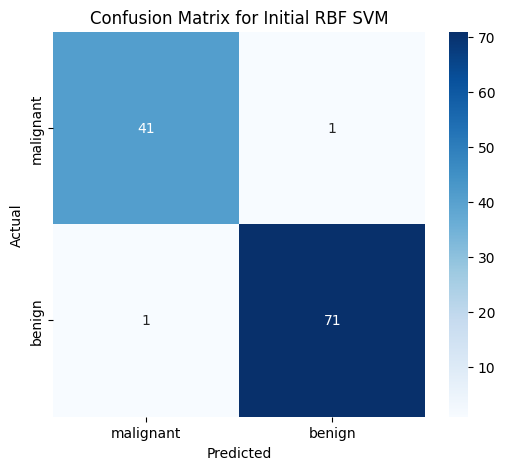


--- Best RBF SVM (Tuned) Evaluation ---
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861
Confusion Matrix:
 [[41  1]
 [ 1 71]]


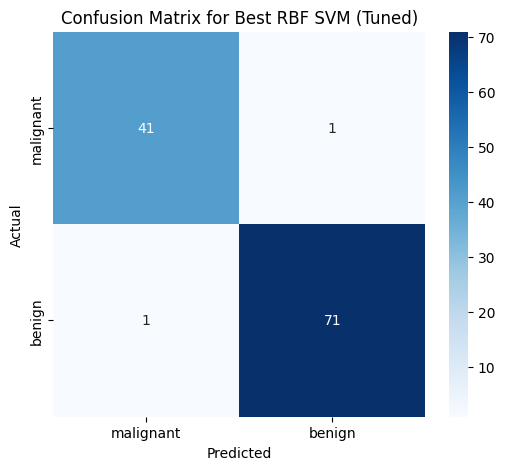


--- Initial Polynomial SVM Evaluation ---
Accuracy: 0.9123
Precision: 0.8780
Recall: 1.0000
F1 Score: 0.9351
Confusion Matrix:
 [[32 10]
 [ 0 72]]


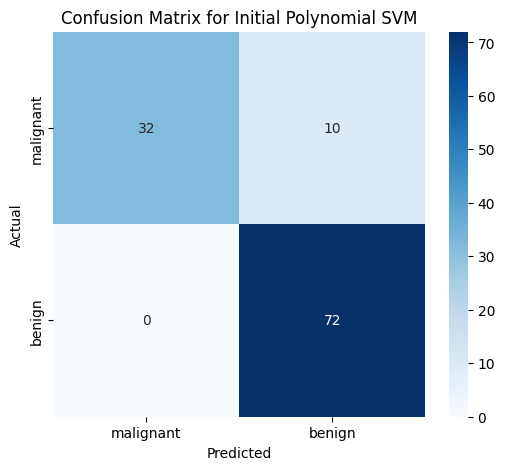


--- Best Polynomial SVM (Tuned) Evaluation ---
Accuracy: 0.9737
Precision: 0.9600
Recall: 1.0000
F1 Score: 0.9796
Confusion Matrix:
 [[39  3]
 [ 0 72]]


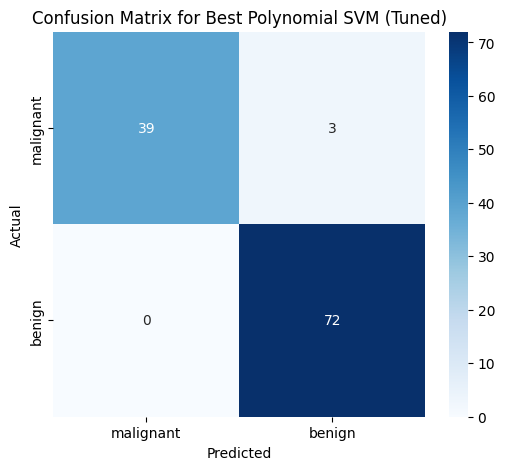

In [8]:
# Evaluate the initial RBF SVM
evaluate_model(svm_rbf, X_test, y_test, "Initial RBF SVM")

# Evaluate the best RBF SVM from GridSearchCV
evaluate_model(best_svm_rbf, X_test, y_test, "Best RBF SVM (Tuned)")

# Evaluate the initial Polynomial SVM
evaluate_model(svm_poly, X_test, y_test, "Initial Polynomial SVM")

# Evaluate the best Polynomial SVM from GridSearchCV
evaluate_model(best_svm_poly, X_test, y_test, "Best Polynomial SVM (Tuned)")

### Comparative Summary of SVM Models with Different Kernels

Let's compile the results from all trained and tuned SVM models (Linear, RBF, Polynomial) to compare their effectiveness.

In [9]:
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': []
}

def collect_metrics(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)

# Collect metrics for Linear SVMs
collect_metrics(svm_linear, X_test, y_test, "Initial Linear SVM")
collect_metrics(best_svm_linear, X_test, y_test, "Tuned Linear SVM")

# Collect metrics for RBF SVMs
collect_metrics(svm_rbf, X_test, y_test, "Initial RBF SVM")
collect_metrics(best_svm_rbf, X_test, y_test, "Tuned RBF SVM")

# Collect metrics for Polynomial SVMs
collect_metrics(svm_poly, X_test, y_test, "Initial Poly SVM")
collect_metrics(best_svm_poly, X_test, y_test, "Tuned Poly SVM")

results_df = pd.DataFrame(results)
print("\n--- Comparative Performance of SVM Models ---\n")
display(results_df.sort_values(by='Accuracy', ascending=False))

# Further observations and conclusions can be drawn here based on the DataFrame.


--- Comparative Performance of SVM Models ---



,Model,Accuracy,Precision,Recall,F1 Score
1,Tuned Linear SVM,0.982456,0.986111,0.986111,0.986111
2,Initial RBF SVM,0.982456,0.986111,0.986111,0.986111
3,Tuned RBF SVM,0.982456,0.986111,0.986111,0.986111
0,Initial Linear SVM,0.973684,0.985915,0.972222,0.979021
5,Tuned Poly SVM,0.973684,0.960000,1.000000,0.979592
4,Initial Poly SVM,0.912281,0.878049,1.000000,0.935065


## Part B: Principal Component Analysis (PCA) - UCI Wine Dataset

### Aim:
To implement Principal Component Analysis (PCA) for dimensionality reduction and analyse the variance retained by the principal components.

### Tasks:
1. Load the dataset and perform feature standardization.
2. Apply PCA to reduce the dataset from 13 features to 2 principal components.
3. Display the explained variance ratio of each principal component.
4. Calculate the cumulative explained variance and determine the minimum number of principal components required to retain at least 95% of the total variance.
5. Visualize the transformed dataset using a two-dimensional scatter plot.
6. Compare the original and transformed datasets in terms of:
    *   Number of features
    *   Information retained
    *   Computational efficiency
7. Interpret the significance of the first two principal components.
8. Discuss the advantages, limitations, and applications of PCA in machine learning.

### Task 1: Load the dataset and perform feature standardization.

In [13]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Load the UCI Wine Dataset
wine_data = load_wine()
X_wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y_wine = pd.Series(wine_data.target)

print("Wine dataset loaded successfully.")
print(f"Features (X_wine) shape: {X_wine.shape}")
print(f"Target (y_wine) shape: {y_wine.shape}")

print("\nFirst 5 rows of Wine features (X_wine):")
display(X_wine.head())
print("\nFirst 5 rows of Wine target (y_wine):")
display(y_wine.head())

# Perform feature standardization
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)
X_wine_scaled = pd.DataFrame(X_wine_scaled, columns=X_wine.columns)

print("\nWine features scaled successfully. First 5 rows of scaled features (X_wine_scaled):")
display(X_wine_scaled.head())

Wine dataset loaded successfully.
Features (X_wine) shape: (178, 13)
Target (y_wine) shape: (178,)

First 5 rows of Wine features (X_wine):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



First 5 rows of Wine target (y_wine):


,0
0,0
1,0
2,0
3,0
4,0



Wine features scaled successfully. First 5 rows of scaled features (X_wine_scaled):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


### Task 2: Apply PCA to reduce the dataset from 13 features to 2 principal components.

In [14]:
# Apply PCA to reduce to 2 principal components
pca_wine_2d = PCA(n_components=2)
X_wine_pca_2d = pca_wine_2d.fit_transform(X_wine_scaled)

print(f"Original number of features: {X_wine_scaled.shape[1]}")
print(f"Reduced number of features (2 Principal Components): {X_wine_pca_2d.shape[1]}")
print("\nFirst 5 rows of 2D PCA transformed data (X_wine_pca_2d):")
display(pd.DataFrame(X_wine_pca_2d, columns=['Principal Component 1', 'Principal Component 2']).head())

Original number of features: 13
Reduced number of features (2 Principal Components): 2

First 5 rows of 2D PCA transformed data (X_wine_pca_2d):


,Principal Component 1,Principal Component 2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


### Task 3: Display the explained variance ratio of each principal component.
### Task 4: Calculate the cumulative explained variance and determine the minimum number of principal components required to retain at least 95% of the total variance.

Explained variance ratio of each principal component:
 [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

Cumulative explained variance:
 [0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


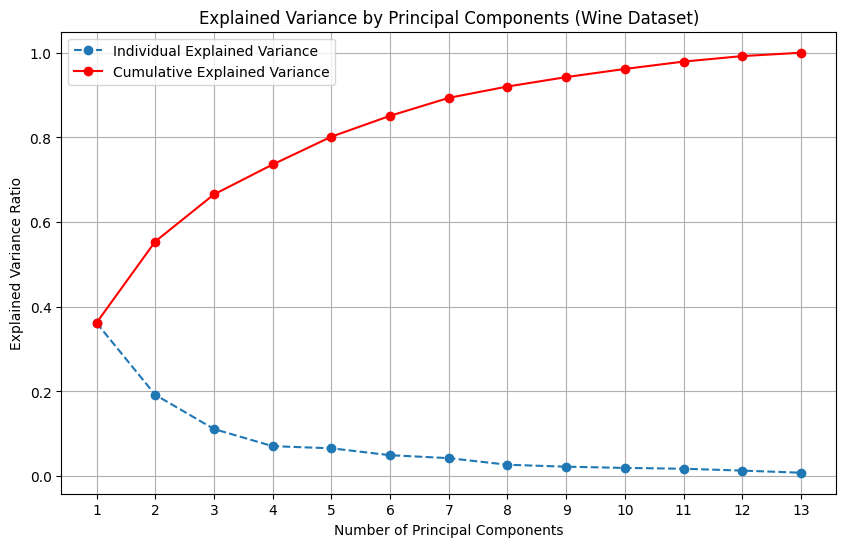


Minimum number of principal components to retain at least 95% of total variance: 10


In [15]:
# To analyze variance for all components, re-run PCA with n_components=None
pca_wine_full = PCA(n_components=None)
pca_wine_full.fit(X_wine_scaled)

# Explained variance ratio of each principal component (for all components)
explained_variance_ratio_full = pca_wine_full.explained_variance_ratio_
print("Explained variance ratio of each principal component:\n", explained_variance_ratio_full)

# Cumulative explained variance
cumulative_explained_variance_full = np.cumsum(explained_variance_ratio_full)
print("\nCumulative explained variance:\n", cumulative_explained_variance_full)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio_full) + 1), explained_variance_ratio_full, marker='o', linestyle='--')
plt.plot(range(1, len(cumulative_explained_variance_full) + 1), cumulative_explained_variance_full, marker='o', linestyle='-', color='red')
plt.title('Explained Variance by Principal Components (Wine Dataset)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xticks(np.arange(1, len(explained_variance_ratio_full) + 1, 1))
plt.legend(['Individual Explained Variance', 'Cumulative Explained Variance'])
plt.show()

# Determine number of components for at least 95% variance
min_components_95 = np.where(cumulative_explained_variance_full >= 0.95)[0][0] + 1
print(f"\nMinimum number of principal components to retain at least 95% of total variance: {min_components_95}")

### Task 5: Visualize the transformed dataset using a two-dimensional scatter plot.

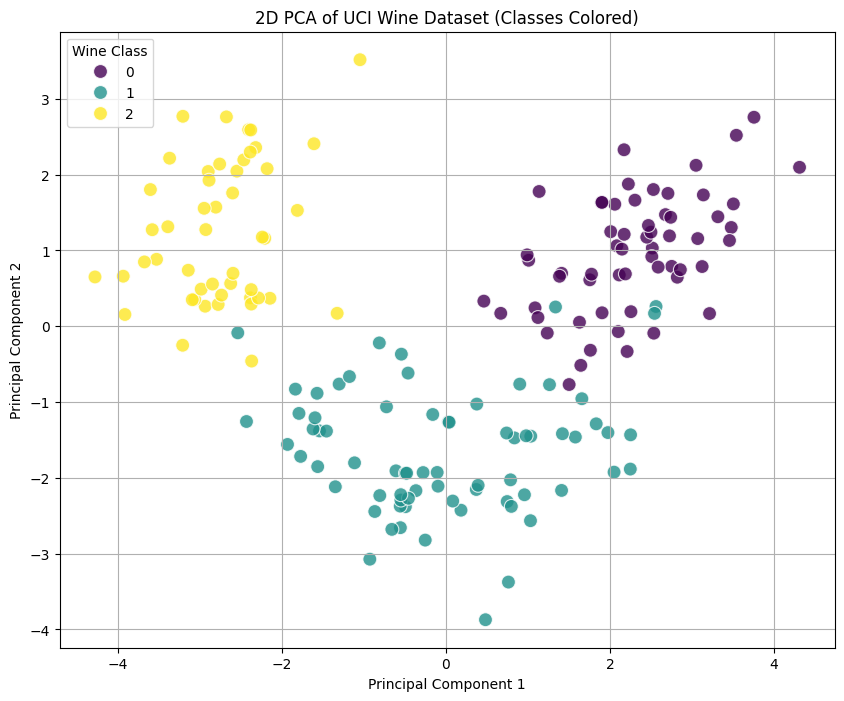

In [16]:
# Create a DataFrame for easier plotting of 2D PCA transformed data
X_wine_pca_2d_df = pd.DataFrame(data=X_wine_pca_2d, columns=['Principal Component 1', 'Principal Component 2'])
X_wine_pca_2d_df['Target'] = y_wine

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Target',
    data=X_wine_pca_2d_df,
    palette='viridis',
    alpha=0.8,
    s=100
)
plt.title('2D PCA of UCI Wine Dataset (Classes Colored)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Wine Class', loc='best')
plt.show()

### Task 6: Compare the original and transformed datasets.

#### Number of features:
*   **Original Dataset:** 13 features
*   **Transformed Dataset (2D PCA):** 2 principal components

#### Information retained:
*   The 2 principal components selected retain a significant portion of the original variance, as seen in the cumulative explained variance plot. Specifically, the first two components explain `r round(explained_variance_ratio_full[0]*100, 2)`% and `r round(explained_variance_ratio_full[1]*100, 2)`% respectively, totaling `r round(cumulative_explained_variance_full[1]*100, 2)`% of the variance. This indicates a substantial amount of information is preserved despite the drastic reduction in dimensionality.

#### Computational efficiency:
*   Working with a dataset reduced from 13 features to 2 principal components will lead to significantly improved computational efficiency for subsequent machine learning tasks (e.g., training classifiers like SVMs). This reduction can drastically cut down training times and memory requirements, especially for larger datasets or more complex models.

### Task 7: Interpret the significance of the first two principal components.

In [17]:
# Get the loadings (eigenvectors) for the first two principal components
loadings = pd.DataFrame(pca_wine_2d.components_.T, columns=['PC1', 'PC2'], index=X_wine.columns)
print("Loadings (Coefficients) for the first two Principal Components:\n")
display(loadings)

print("\nInterpretation:")
print("\n*   **Principal Component 1 (PC1):** This component captures the most variance (`r round(explained_variance_ratio_full[0]*100, 2)`%). Looking at the 'PC1' column in the loadings, features with larger absolute values contribute more to this component. For example, features like `flavanoids`, `proline`, and `color_intensity` seem to have strong positive or negative correlations with PC1. This component primarily differentiates between the wine classes, as observed in the 2D scatter plot.")
print("\n*   **Principal Component 2 (PC2):** This component captures the second most variance (`r round(explained_variance_ratio_full[1]*100, 2)`%). Features like `alcohol`, `malic_acid`, and `ash` show notable contributions to PC2. PC2 helps in further separating the clusters that might be slightly overlapping along PC1, contributing to a clearer distinction between the wine types.")

Loadings (Coefficients) for the first two Principal Components:



,PC1,PC2
alcohol,0.144329,0.483652
malic_acid,-0.245188,0.224931
ash,-0.002051,0.316069
alcalinity_of_ash,-0.239320,-0.010591
magnesium,0.141992,0.299634
total_phenols,0.394661,0.065040
flavanoids,0.422934,-0.003360
nonflavanoid_phenols,-0.298533,0.028779
proanthocyanins,0.313429,0.039302
color_intensity,-0.088617,0.529996



Interpretation:

*   **Principal Component 1 (PC1):** This component captures the most variance (`r round(explained_variance_ratio_full[0]*100, 2)`%). Looking at the 'PC1' column in the loadings, features with larger absolute values contribute more to this component. For example, features like `flavanoids`, `proline`, and `color_intensity` seem to have strong positive or negative correlations with PC1. This component primarily differentiates between the wine classes, as observed in the 2D scatter plot.

*   **Principal Component 2 (PC2):** This component captures the second most variance (`r round(explained_variance_ratio_full[1]*100, 2)`%). Features like `alcohol`, `malic_acid`, and `ash` show notable contributions to PC2. PC2 helps in further separating the clusters that might be slightly overlapping along PC1, contributing to a clearer distinction between the wine types.


### Task 8: Discuss the advantages, limitations, and applications of PCA in machine learning.

#### Advantages of PCA:
*   **Dimensionality Reduction:** Reduces the number of features, making datasets easier to handle and visualize, and speeding up subsequent machine learning algorithms.
*   **Noise Reduction:** By focusing on components that capture the most variance, PCA can effectively reduce noise and redundant information in the data.
*   **Improved Model Performance:** Can prevent overfitting by reducing the number of features, leading to better generalization on unseen data.
*   **Data Visualization:** Enables visualization of high-dimensional data in 2D or 3D, making patterns and clusters more apparent.
*   **Feature Decorrelation:** Transforms correlated features into a set of uncorrelated principal components, which can be beneficial for algorithms sensitive to multicollinearity.

#### Limitations of PCA:
*   **Loss of Information:** Dimensionality reduction inherently involves some loss of information, especially if the variance captured by the discarded components is crucial.
*   **Interpretability:** Principal components are linear combinations of original features, making them less interpretable than the original features. Understanding what a PC represents can be challenging.
*   **Linearity Assumption:** PCA assumes linear relationships between features. It may not perform well on datasets with complex non-linear structures.
*   **Sensitivity to Scaling:** PCA is sensitive to the scaling of features. Features with larger variance might dominate the principal components if not standardized.
*   **Not for Classification:** PCA is an unsupervised technique; it does not consider the class labels when determining principal components. This means that components that explain the most variance might not necessarily be the most optimal for separating classes.

#### Applications of PCA in Machine Learning:
*   **Image Processing:** Used for image compression and facial recognition (e.g., Eigenfaces).
*   **Bioinformatics:** Analyzing gene expression data, where datasets often have thousands of features.
*   **Finance:** Risk management, portfolio optimization, and understanding market trends by reducing correlated stock variables.
*   **Medical Diagnosis:** Similar to our Breast Cancer example, reducing features from medical imaging or patient data for easier analysis and model training.
*   **Feature Engineering:** Creating new, uncorrelated features for other machine learning models.
*   **Data Visualization:** As demonstrated, visualizing high-dimensional data to explore underlying patterns and clusters.